In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    accuracy_score
)

In [4]:

# ==========================================
# 1. DATA LOADING & CLEANING
# ==========================================
df = pd.read_csv('Autocomp - Companies list (CA-1).csv')
df.columns = df.columns.str.strip()
df = df.drop_duplicates()
df = df.dropna()
df = df.replace([np.inf, -np.inf], np.nan)
df = df.reset_index(drop=True)
print(df.shape)
print(df.info())
print(df.describe())
print(df.isna().sum())
print(df.nunique())

def clean_numeric(val):
    if pd.isna(val):
        return np.nan
    match = re.search(r'(\d+\.?\d*)', str(val))
    return float(match.group(1)) if match else np.nan

df['Rev'] = df['Revenue'].apply(clean_numeric)
df['Ebt'] = df['EBITDA (IN MILLIONS)'].apply(clean_numeric)
df['List'] = df['Listed'].str.strip().str.upper().map({'YES': 1, 'NO': 0})

df_ml = df.dropna(subset=['Rev', 'Ebt']).copy()
df.head(5)

(236, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 236 entries, 0 to 235
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Name of the company   236 non-null    object
 1   Location              236 non-null    object
 2   Listed                236 non-null    object
 3   Products              236 non-null    object
 4   Revenue               236 non-null    object
 5   EBITDA (IN MILLIONS)  236 non-null    object
 6   Website               236 non-null    object
dtypes: object(7)
memory usage: 13.0+ KB
None
                         Name of the company Location Listed  \
count                                    236      236    236   
unique                                   236       38      2   
top     ABILITIES INDIA PISTONS & RINGS LTD.  HARYANA     NO   
freq                                       1       34    209   

                Products         Revenue EBITDA (IN MILLIONS)  \
count

,Name of the company,Location,Listed,Products,Revenue,EBITDA (IN MILLIONS),Website,Rev,Ebt,List
0,ABILITIES INDIA PISTONS & RINGS LTD.,DELHI,NO,PISTON AND RINGS,1103.43 (2023),140.41 (2023),http://aippistons.com/,1103.43,140.41,0
1,ACCOLADE ELECTRONICS PRIVATE LIMITED,PUNE,NO,"LED (light-emitting diode) emergency light, in...",1275.45 (2023),146.97 (2023),http://accoladeelectronics.com/,1275.45,146.97,0
2,ADITYA AUTOS,BANGALORE,NO,"window regulators, door latches, tailgate latc...",6384.40 (2024),357.20 (2024),http://www.adityaauto.com/,6384.40,357.20,0
3,ADVIK HI-TECH PRIVATE LIMITED,PUNE,NO,"lifter tensioner, oil pumps, fuel cocks – man...",6771.60 (2024),1724.9 (2024),http://www.advik.co.in/,6771.60,1724.90,0
4,ALF ENGINEERING PVT. LTD.,MUMBAI,NO,"chassis, hydroformed parts, suspension assembl...",13920.06 (2023),1526.56 (2023),http://www.alfengineering.com/,13920.06,1526.56,0



--- CLUSTERING METRICS ---
KMeans Silhouette Score        : 0.851
Agglomerative Silhouette Score : 0.788


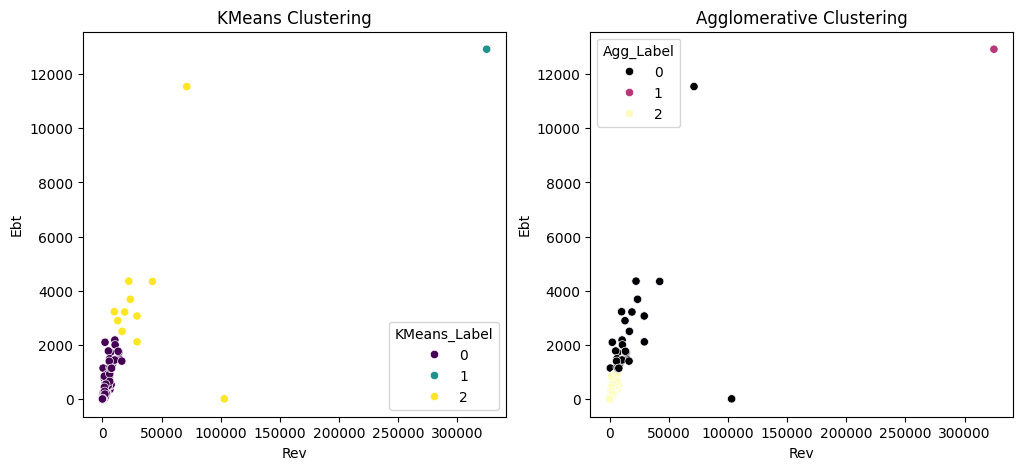

In [11]:
# ==========================================
# 2. CLUSTERING ALGORITHMS
# ==========================================
X_cluster = StandardScaler().fit_transform(df_ml[['Rev', 'Ebt']])

# ---- KMeans ----
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_ml['KMeans_Label'] = kmeans.fit_predict(X_cluster)
kmeans_silhouette = silhouette_score(X_cluster, df_ml['KMeans_Label'])

# ---- Agglomerative ----
agg = AgglomerativeClustering(n_clusters=3)
df_ml['Agg_Label'] = agg.fit_predict(X_cluster)
agg_silhouette = silhouette_score(X_cluster, df_ml['Agg_Label'])

print("\n--- CLUSTERING METRICS ---")
print(f"KMeans Silhouette Score        : {kmeans_silhouette:.3f}")
print(f"Agglomerative Silhouette Score : {agg_silhouette:.3f}")

# Scatter plots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_ml, x='Rev', y='Ebt', hue='KMeans_Label', palette='viridis')
plt.title('KMeans Clustering')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_ml, x='Rev', y='Ebt', hue='Agg_Label', palette='magma')
plt.title('Agglomerative Clustering')

plt.show()



--- REGRESSION METRICS ---
Linear Regression R²   : 0.504
Linear Regression RMSE : 479.171
Random Forest R²       : 0.561
Random Forest RMSE     : 451.103

--- RANDOM FOREST METRICS ---
R² Score           : 0.561
RMSE               : 451.103
MAE                : 218.758
MSE                : 203494.327


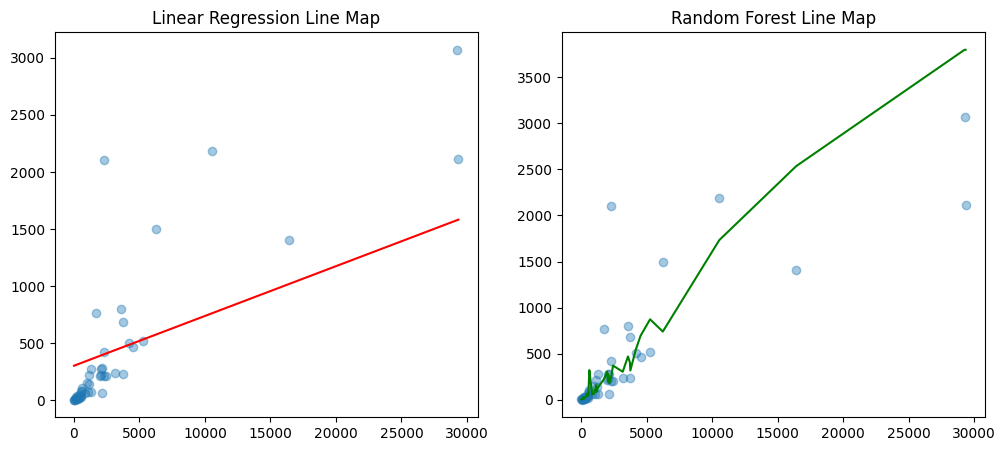

In [18]:
# ==========================================
# 3. REGRESSION ALGORITHMS
# ==========================================
X = df_ml[['Rev']]
y = df_ml['Ebt']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- Linear Regression ----
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_r2 = r2_score(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# ---- Random Forest Regression ----
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)



print("\n--- REGRESSION METRICS ---")
print(f"Linear Regression R²   : {lr_r2:.3f}")
print(f"Linear Regression RMSE : {lr_rmse:.3f}")
print(f"Random Forest R²       : {rf_r2:.3f}")
print(f"Random Forest RMSE     : {rf_rmse:.3f}")

print("\n--- RANDOM FOREST METRICS ---")
print(f"R² Score           : {rf_r2:.3f}")
print(f"RMSE               : {rf_rmse:.3f}")
print(f"MAE                : {rf_mae:.3f}")
print(f"MSE                : {rf_mse:.3f}")

# Line plots
plot_df = pd.DataFrame({
    'Rev': X_test['Rev'],
    'Actual': y_test,
    'LR_Pred': lr_pred,
    'RF_Pred': rf_pred
}).sort_values(by='Rev')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(plot_df['Rev'], plot_df['Actual'], alpha=0.4)
plt.plot(plot_df['Rev'], plot_df['LR_Pred'], color='red')
plt.title('Linear Regression Line Map')

plt.subplot(1, 2, 2)
plt.scatter(plot_df['Rev'], plot_df['Actual'], alpha=0.4)
plt.plot(plot_df['Rev'], plot_df['RF_Pred'], color='green')
plt.title('Random Forest Line Map')

plt.show()


--- SVM CLASSIFICATION METRICS ---
SVM Training Accuracy : 88.30%
SVM Testing Accuracy  : 89.58%


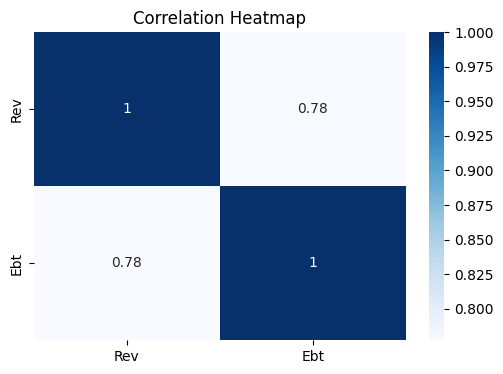

In [10]:

# ==========================================
# 4. SVM CLASSIFICATION
# ==========================================
df_svm = df_ml.dropna(subset=['List'])

X_svm = df_svm[['Rev', 'Ebt']]
y_svm = df_svm['List']

scaler = StandardScaler()
X_svm_scaled = scaler.fit_transform(X_svm)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_svm_scaled, y_svm, test_size=0.2, random_state=42
)

svm = SVC(kernel='linear')
svm.fit(X_train_s, y_train_s)

svm_train_acc = accuracy_score(y_train_s, svm.predict(X_train_s))
svm_test_acc = accuracy_score(y_test_s, svm.predict(X_test_s))

print("\n--- SVM CLASSIFICATION METRICS ---")
print(f"SVM Training Accuracy : {svm_train_acc:.2%}")
print(f"SVM Testing Accuracy  : {svm_test_acc:.2%}")

# ==========================================
# 5. ADDITIONAL INSIGHT MAPS
# ==========================================
# Correlation Heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df_ml[['Rev', 'Ebt']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

